# Miscellaneous Analyses

## Purpose: 

This is meant for mini-analyses and questions that need answered that don't fall into the normal workflow. 

## Packages and Options

In [30]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob, pickle, seaborn  
import matplotlib.pyplot as plt

## Confirm that the relative scores from `JASPAR 2022` are ranks

In [72]:
rank_observation_num_differences = []

for file in glob.glob("2_get_data/outputs/*"): 
    
    tmp_df = pd.read_csv(file, sep="\t", header=None)
    tmp_df = tmp_df[[4]]
        
    if tmp_df[4].min()!=800: 
        "Min not 800 {}".format(file)
        tmp_df[4].min()
        
    if tmp_df[4].max()!=1000: 
        "Max not 1000 {}".format(file)
        tmp_df[4].max()
    
    rank_observation_num_differences.append(
        abs(
            (tmp_df[tmp_df[4]<900].index.size) - (tmp_df[tmp_df[4]>900].index.size)
        )
    )

'Max not 1000 2_get_data/outputs/MA1114.1.tsv'

998

<Figure size 1200x800 with 0 Axes>

/apps/software/standard/compiler/gcc/9.2.0/jupyter_conda/2020.11-py3.8/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:>

Text(0.5, 0.98, 'Absolute Value Difference Between Number of JASPAR \n Predictions with Relative Score < 900 and > 900 \n 24 dots correspond to 24 TFs and ideally this should be 24 zeros')

(-0.1, 0.1)

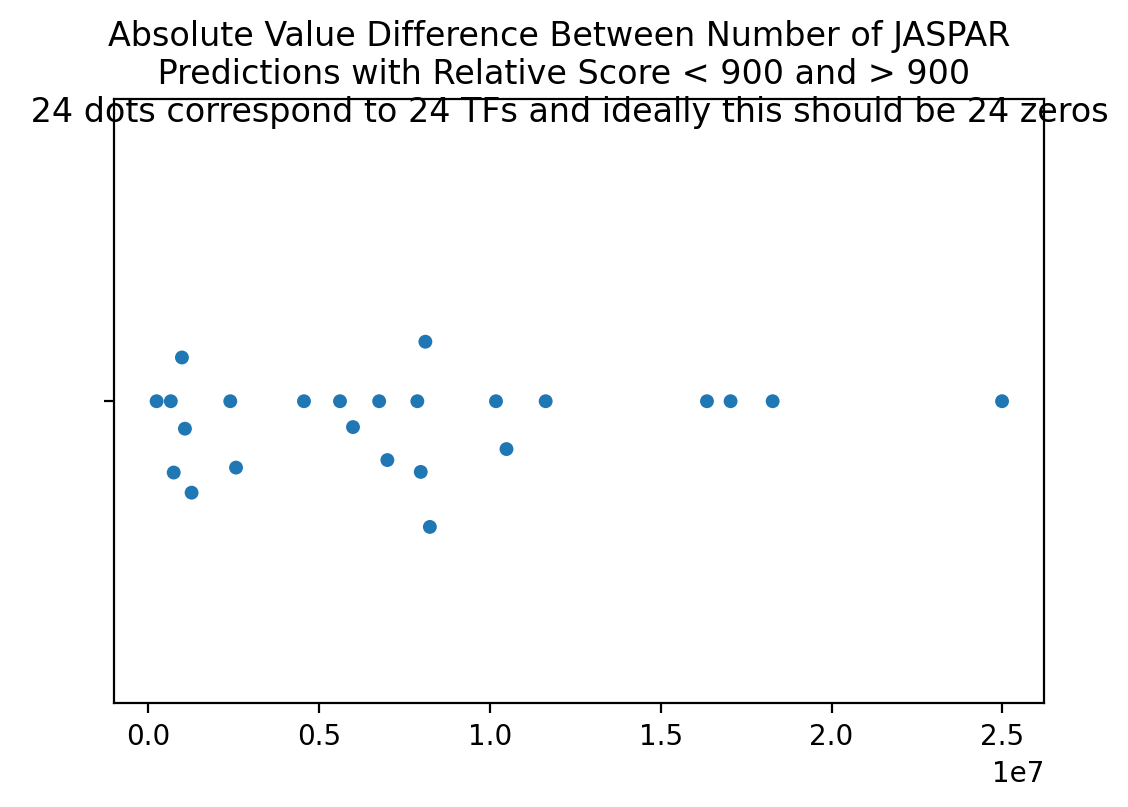

In [83]:
plt.figure(dpi=200)

seaborn.swarmplot(rank_observation_num_differences)

plt.suptitle("Absolute Value Difference Between Number of JASPAR \n Predictions with Relative Score < 900 and > 900 \n 24 dots correspond to 24 TFs and ideally this should be 24 zeros")

plt.ylim(-0.1, 0.1)

## Load Differential Expression Genes-TF Networks

In [ ]:
files = glob.glob("../../outputs/pickled_networks/differential_expression_tf_networks/*")

files

In [ ]:
diff_expression_tf_networks = {}

for file in files:
    
    parameter_combination = file.split("/")[-1].split(".")[0]
    diff_expression_tf_networks[parameter_combination] = pickle.load(open(file, 'rb'))
    
    

In [ ]:
for key in diff_expression_tf_networks: 
    diff_expression_tf_networks[key]

In [ ]:
diff_expression_tf_networks[key].